In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from omegaconf import OmegaConf

def collect_sweep_results(multirun_dir):
    rows = []
    base_path = Path(multirun_dir)
    
    if not base_path.exists():
        print(f"Error: Directory not found: {base_path}")
        return pd.DataFrame()

    config_files = list(base_path.rglob("config.yaml"))
    if not config_files:
        print(f"No config files found in {base_path}")
        return pd.DataFrame()

    # 抽出したいパラメータのリスト（ここに追加するだけでOK）
    target_params = [
        "reg"
    ]
    
    # --- スイープパラメータの事前解析 ---
    sweep_summary = {k: set() for k in target_params}
    
    for cp in config_files:
        temp_cfg = OmegaConf.load(cp)
        for key in target_params:
            # 直下または task 配下から取得
            val = temp_cfg.get(key)
            if val is None and 'task' in temp_cfg:
                val = temp_cfg.task.get(key)
            if val is not None:
                sweep_summary[key].add(val)

    print("=" * 40)
    print(f"Sweep Summary: {base_path.name}")
    for key, values in sweep_summary.items():
        if values:
            sorted_vals = sorted(list(values))
            print(f"  {key:18}: {sorted_vals} (n={len(sorted_vals)})")
    print("-" * 40)
    print(f"Total job directories: {len(config_files)}")
    print("=" * 40)

    # --- データ収集 ---
    for config_path in config_files:
        job_dir = config_path.parent.parent if ".hydra" in str(config_path) else config_path.parent
        data_path = job_dir / "data" / "classification_results.npz"
        
        if data_path.exists():
            try:
                cfg = OmegaConf.load(config_path)
                data = np.load(data_path)
                
                # パラメータ抽出用の共通処理
                def get_val(k):
                    v = cfg.get(k)
                    return v if v is not None or 'task' not in cfg else cfg.task.get(k)

                # 行データの構築
                row = {k: get_val(k) for k in target_params}
                
                # 精度計算
                conf_mat = data['confusion_matrix']
                total = np.sum(conf_mat)
                acc = np.trace(conf_mat) / total if total > 0 else np.nan
                
                row["accuracy"] = acc
                row["job_id"] = job_dir.name
                rows.append(row)
                
            except Exception as e:
                print(f"Skipping {job_dir.name} due to error: {e}")

    df = pd.DataFrame(rows)
    
    if not df.empty:
        # ソート対象を動的に設定（存在する列のみ）
        sort_cols = [c for c in target_params if c in df.columns]
        df = df.sort_values(sort_cols).reset_index(drop=True)
        print(f"\nSuccessfully collected {len(df)} / {len(config_files)} results.")
    else:
        print("\nNo results found. Please check data existence.")

    return df

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # ジッター付与に使用

def plot_results(df):
    # 1. データが入っているかチェック
    if df.empty:
        print("Error: DataFrame is empty.")
        return

    # 2. 対象パラメータの存在確認
    target_params = ["reg"]
    available_params = [p for p in target_params if p in df.columns]
    
    if not available_params:
        print(f"Error: Target parameters {target_params} not found.")
        return

    # 3. スイープ（2種類以上の値がある）されているパラメータを特定
    sweep_params = [p for p in available_params if df[p].nunique() > 1]
    
    print(f"Detected sweep parameters: {sweep_params}")

    plt.figure(figsize=(12, 8))
    sns.set_context("talk")
    sns.set_style("whitegrid")

    # --- パターンA: 2変数以上のスイープ (ヒートマップ) ---
    if len(sweep_params) >= 2:
        # ヒートマップは平均値のみを表示（データ点プロットは複雑になるため）
        p1, p2 = sweep_params[0], sweep_params[1]
        print(f"Plotting 2D Sweep Heatmap: {p1} vs {p2}")
        pivot_df = df.groupby([p1, p2])['accuracy'].mean().unstack()
        
        sns.heatmap(pivot_df, annot=True, cmap="viridis", fmt=".3f",
                    cbar_kws={'label': 'Mean Accuracy'})
        plt.title(f"Accuracy Heatmap\n({p1} vs {p2})")

    # --- パターンB: 1変数スイープ (折れ線グラフ + データ点) ---
    elif len(sweep_params) == 1:
        param = sweep_params[0]
        print(f"Plotting 1D Sweep Lineplot with Data Points: {param}")
        
        # 1. まず、生のデータ点をプロット (Scatterplot)
        #   点同士の重なりを避けるため、x軸方向に少しジッター（散らばり）を加える
        df_plot = df.copy()
        
        # パラメータが数値の場合のみジッターを加える
        if np.issubdtype(df_plot[param].dtype, np.number):
            # x軸の範囲に合わせてジッターの幅を調整（最小間隔の10%程度）
            unique_vals = np.sort(df_plot[param].unique())
            # 修正: 最小値が0以下の場合は対数軸にできないためチェック
            if (unique_vals <= 0).any():
                print(f"Warning: Proposing log scale, but contains 0 or negative values in {param}. Plotting in linear scale instead.")
                is_log = False
            else:
                is_log = True
            if len(unique_vals) > 1:
                rng = np.random.default_rng(seed=42) 
                
                if is_log:
                    # 【修正】対数空間での最小間隔の10%を計算し、乗算/除算の形でジッターを付与
                    log_vals = np.log10(unique_vals)
                    min_diff_log = np.min(np.diff(log_vals))
                    jitter_width_log = min_diff_log * 0.1
                    
                    # 対数空間で一様乱数を足してから元に戻す
                    rand_jitter = rng.uniform(-jitter_width_log, jitter_width_log, len(df_plot))
                    df_plot[param] = df_plot[param] * (10 ** rand_jitter)
                else:
                    # 従来の線形ジッター
                    min_diff = np.min(np.diff(unique_vals))
                    jitter_width = min_diff * 0.1
                    df_plot[param] = df_plot[param] + rng.uniform(-jitter_width, jitter_width, len(df_plot))

        sns.scatterplot(data=df_plot, x=param, y="accuracy", 
                        alpha=0.4,     
                        color="gray",   
                        s=60,          
                        label='Raw Data (per seed)',
                        legend=False)   

        sns.lineplot(data=df, x=param, y="accuracy", marker='o', 
                    color="tab:blue", 
                    linewidth=2.5,   
                    markersize=10,   
                    errorbar='sd', err_style="bars", err_kws={'capsize': 5},
                    label='Mean ± SD')

        # 【追加】x軸を対数軸に設定（0チェックを通過した場合のみ）
        if np.issubdtype(df[param].dtype, np.number) and (df[param] > 0).all():
            plt.xscale('log')

        plt.title(f"Accuracy vs {param}\n(n_seeds={df['seed'].nunique()})")
        plt.legend(loc='best')

    # --- パターンC: 全て固定値 (箱ひげ図) ---
    else:
        print("Plotting Distribution for Fixed Parameters")
        sns.boxplot(data=df, y="accuracy", color="skyblue", width=0.4)
        sns.stripplot(data=df, y="accuracy", color="black", alpha=0.5, size=8)
        plt.title("Accuracy Distribution (Fixed Parameters)")

    plt.tight_layout()
    # コマンド履歴が残るよう、ファイル名にスイープ変数をIDとして含めるのが通例
    fig_id = "_".join(sweep_params) if sweep_params else "fixed"
    plt.savefig(f'accuracy_vs_{fig_id}.png', dpi=300)
    plt.show()

Sweep Summary: 13-30-48
  reg               : [1e-12, 1e-11, 1e-10, 1e-09, 1e-08, 1e-07] (n=6)
----------------------------------------
Total job directories: 120

Successfully collected 118 / 120 results.
Detected sweep parameters: ['reg']
Plotting 1D Sweep Lineplot with Data Points: reg


KeyError: 'seed'

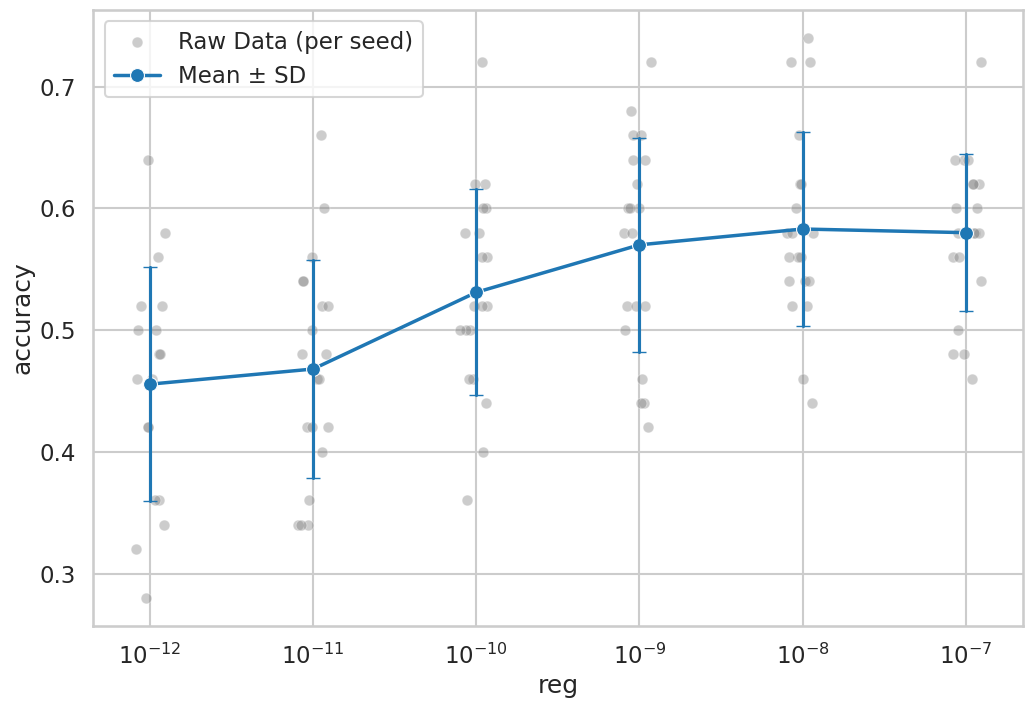

In [3]:
df = collect_sweep_results("../multirun/2026-06-01/13-30-48") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   reg       118 non-null    float64
 1   accuracy  118 non-null    float64
 2   job_id    118 non-null    str    
dtypes: float64(2), str(1)
memory usage: 2.9 KB


In [10]:
# 1. 基本統計量を確認し、最小値・最大値に不自然な値（-1や0など）がないか見る
print(df.describe())

# 2. 無限大 (inf) が混入していないか確認
import numpy as np
print("infの件数:", np.isinf(df[['reg', 'accuracy']]).sum())

# 3. job_id に空文字や、予期せぬ文字列が含まれていないか確認
print("空文字の件数:", (df['job_id'] == "").sum())
print("ユニークな job_id の数:", df['job_id'].nunique())

                reg    accuracy
count  1.180000e+02  118.000000
mean   1.883236e-08    0.532542
std    3.699972e-08    0.097272
min    1.000000e-12    0.280000
25%    1.000000e-11    0.460000
50%    1.000000e-09    0.540000
75%    1.000000e-08    0.600000
max    1.000000e-07    0.740000
infの件数: reg         0
accuracy    0
dtype: int64
空文字の件数: 0
ユニークな job_id の数: 118


In [11]:
# 本来実験として回したはずの reg の値の設計リスト（例）
# expected_regs = [0.1, 0.2, ...] 

# 実際にデータに存在する reg の組み合わせの頻度をカウントする
print(df['reg'].value_counts().sort_index())

reg
1.000000e-12    18
1.000000e-11    20
1.000000e-10    20
1.000000e-09    20
1.000000e-08    20
1.000000e-07    20
Name: count, dtype: int64
